# TP - Classification de cartes magnétiques
## Détection de fourreaux souterrains par apprentissage profond
**Formation :** 2ème année Data IA  
**Date de rendu :** 11 juin 2025 à 17h00

## Installation des dépendances

In [1]:
# Installe les bibliothèques nécessaires
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn opencv-python pillow -q

## Connexion Google Drive

In [2]:
import os
from google.colab import drive

drive.mount("/content/drive")

DATA_DIR = "/content/data/Training_database_float16"
SAVE_DIR = "/content/drive/MyDrive/TP1_models"
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
import zipfile

ZIP_PATH = "/content/drive/MyDrive/Training_database_float16.zip"
EXTRACT_DIR = "/content/data"

if not os.path.exists(DATA_DIR):
    print("Extraction du zip en cours...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print("Terminé.")
else:
    print("Données déjà extraites.")

Extraction du zip en cours...
Terminé.


CSV_PATH = os.path.join(DATA_DIR, "pipe_detection_label.csv")

# Charge le fichier labels
df = pd.read_csv(CSV_PATH, sep=";")
print("Shape:", df.shape)
df.head()

In [4]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0

print(f"TensorFlow : {tf.__version__}")
print(f"GPU disponible : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.20.0
GPU disponible : []


---
# Partie I — Exploration et prétraitement des données

## 1) Chargement et exploration du dataset

In [5]:
CSV_PATH = os.path.join(DATA_DIR, "pipe_detection_label.csv")

# Charge le fichier labels
df = pd.read_csv(CSV_PATH, sep=";")
print("Shape:", df.shape)
df.head()

Shape: (2833, 8)


,field_file,label,width_m,coverage_type,shape,noisy,noise_type,pipe_type
0,sample_00000_perfect_straight_clean_field.npz,1,62.40,perfect,straight,False,NaN,single
1,sample_00001_perfect_straight_clean_field.npz,1,41.08,perfect,straight,False,NaN,single
2,sample_00002_perfect_straight_clean_field.npz,1,42.34,perfect,straight,False,NaN,single
3,sample_00003_perfect_straight_clean_field.npz,1,4.96,perfect,straight,False,NaN,single
4,sample_00004_perfect_straight_clean_field.npz,1,35.96,perfect,straight,False,NaN,single


In [6]:
# Distribution des classes
print("Distribution des labels :")
print(df["label"].value_counts())
print(f"\nTaux de déséquilibre : {df['label'].value_counts()[1] / len(df):.2%} positifs")

Distribution des labels :
label
1    1700
0    1133
Name: count, dtype: int64

Taux de déséquilibre : 60.01% positifs


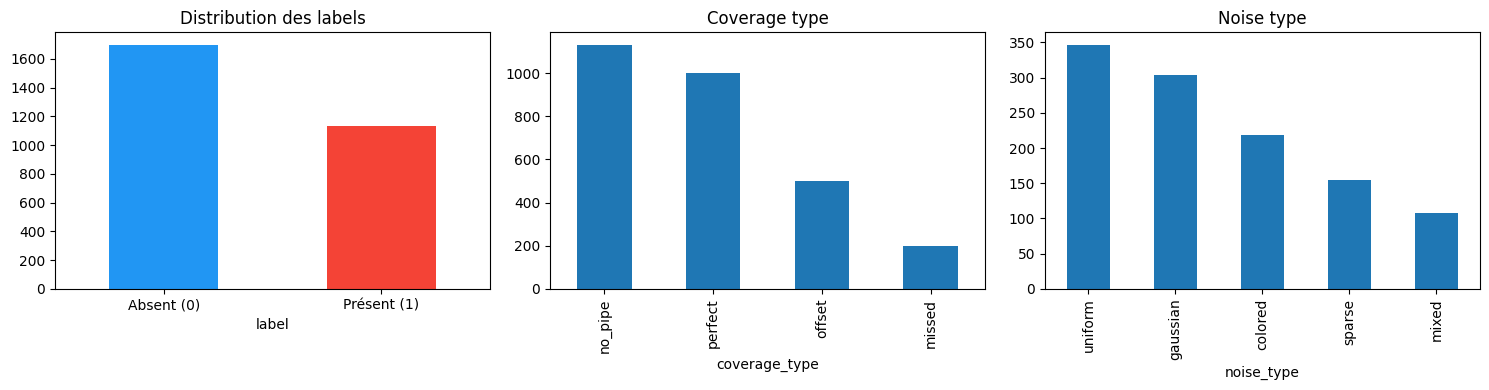

In [7]:
# Visualise la distribution des classes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["label"].value_counts().plot(kind="bar", ax=axes[0], color=["#2196F3", "#F44336"])
axes[0].set_title("Distribution des labels")
axes[0].set_xticklabels(["Absent (0)", "Présent (1)"], rotation=0)

df["coverage_type"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Coverage type")

df["noise_type"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Noise type")

plt.tight_layout()
plt.show()

In [8]:
def load_npz(filename):
    """Charge un fichier npz."""
    path = os.path.join(DATA_DIR, filename)
    sample = np.load(path, allow_pickle=True)
    return sample["data"].astype(np.float32)


# Inspecte les 8 premiers fichiers
for fname in df["field_file"].iloc[:8]:
    data = load_npz(fname)
    nan_pct = np.isnan(data).mean() * 100
    print(f"{fname:<60} shape={data.shape}  nan={nan_pct:.1f}%  "
          f"min={np.nanmin(data):.2f}  max={np.nanmax(data):.2f}")

sample_00000_perfect_straight_clean_field.npz                shape=(853, 901, 4)  nan=57.7%  min=0.00  max=29.48
sample_00001_perfect_straight_clean_field.npz                shape=(240, 307, 4)  nan=14.5%  min=0.01  max=79.00
sample_00002_perfect_straight_clean_field.npz                shape=(1193, 1248, 4)  nan=77.4%  min=0.00  max=63.94
sample_00003_perfect_straight_clean_field.npz                shape=(1247, 1053, 4)  nan=97.0%  min=0.00  max=547.00
sample_00004_perfect_straight_clean_field.npz                shape=(1045, 1004, 4)  nan=77.2%  min=0.00  max=1514.00
sample_00005_perfect_straight_clean_field.npz                shape=(1136, 698, 4)  nan=91.4%  min=0.01  max=382.25
sample_00006_perfect_straight_clean_field.npz                shape=(184, 434, 4)  nan=43.0%  min=0.01  max=83.81
sample_00007_perfect_straight_clean_field.npz                shape=(173, 150, 4)  nan=80.2%  min=0.31  max=1015.00


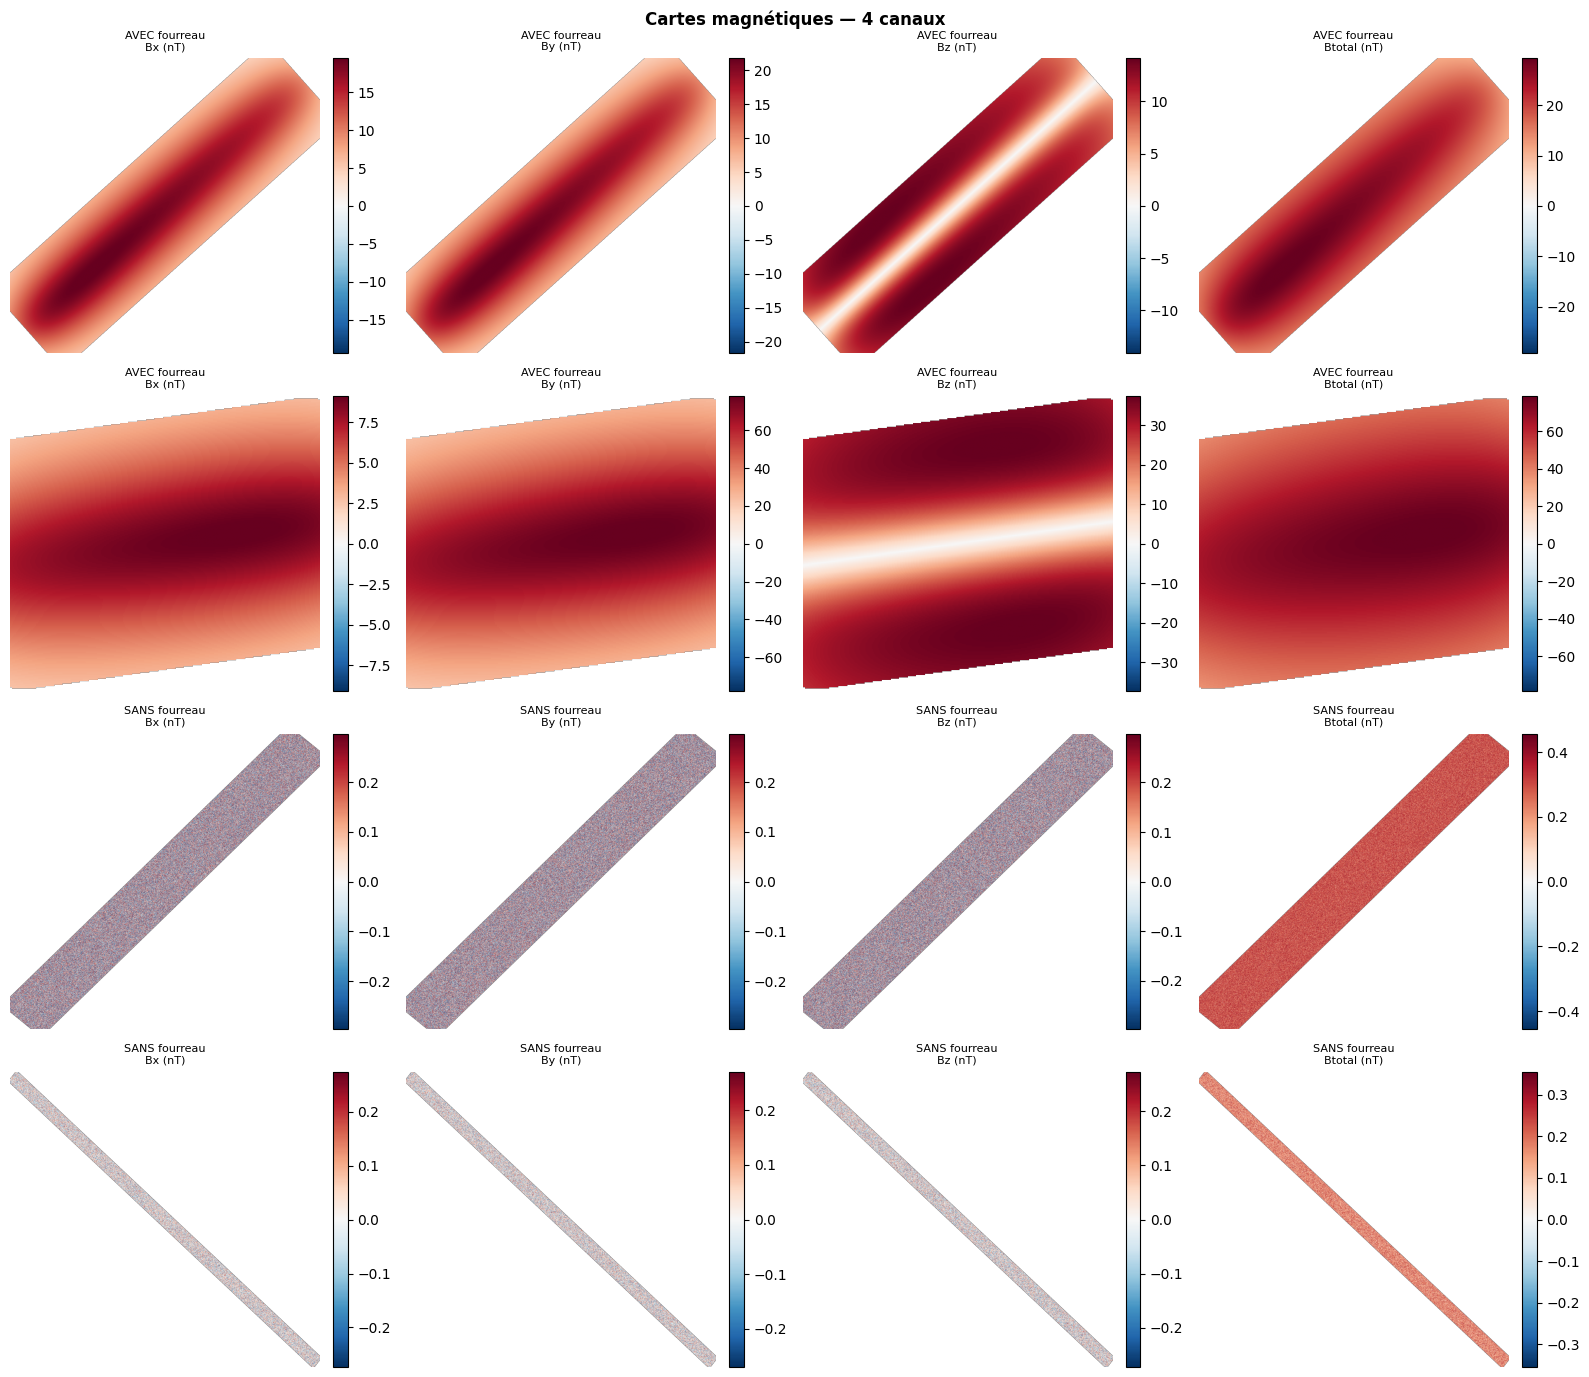

In [9]:
CHANNEL_NAMES = ["Bx (nT)", "By (nT)", "Bz (nT)", "Btotal (nT)"]


def plot_sample(fname, label, ax_row):
    """Affiche les 4 canaux d'un échantillon."""
    data = load_npz(fname)
    title_prefix = "AVEC fourreau" if label == 1 else "SANS fourreau"
    for c, ax in enumerate(ax_row):
        channel = data[:, :, c]
        vmax = np.nanpercentile(np.abs(channel), 99)
        im = ax.imshow(channel, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_title(f"{title_prefix}\n{CHANNEL_NAMES[c]}", fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.axis("off")


samples_pos = df[df["label"] == 1]["field_file"].iloc[:2].tolist()
samples_neg = df[df["label"] == 0]["field_file"].iloc[:2].tolist()
samples = [(f, 1) for f in samples_pos] + [(f, 0) for f in samples_neg]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for row, (fname, lbl) in enumerate(samples):
    plot_sample(fname, lbl, axes[row])

plt.suptitle("Cartes magnétiques — 4 canaux", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations :**
- Les cartes **avec fourreau** présentent une anomalie dipôlaire marquée (alternance rouge/bleu intense sur Bz et Btotal).
- Les cartes **sans fourreau** montrent un signal homogène de faible amplitude, dominé par du bruit diffus.
- La composante **Btotal** est la plus discriminante visuellement.

## 2) Prétraitement des données

### Gestion des NaN
Remplacement par la **médiane du canal** : robuste aux outliers, préserve l'ordre de grandeur physique.

### Redimensionnement
Taille cible **128×128** : conserve les structures dipôlaires sans alourdir le calcul.

### Normalisation
**Z-score par canal**, statistiques calculées sur le train set uniquement (pas de data leakage).

In [10]:
IMG_SIZE = 64   # réduit pour Colab gratuit


def fill_nan_median(data):
    """Remplace NaN par médiane canal."""
    result = data.copy()
    for c in range(data.shape[2]):
        channel = result[:, :, c]
        channel[np.isnan(channel)] = np.nanmedian(channel)
    return result


def resize_map(data, size=IMG_SIZE):
    """Redimensionne la carte magnétique."""
    resized = np.zeros((size, size, 4), dtype=np.float32)
    for c in range(4):
        resized[:, :, c] = cv2.resize(
            data[:, :, c], (size, size), interpolation=cv2.INTER_LINEAR
        )
    return resized


def compute_channel_stats(X):
    """Calcule mean/std sur train set."""
    mean = X.mean(axis=(0, 1, 2), keepdims=True)
    std = X.std(axis=(0, 1, 2), keepdims=True) + 1e-8
    return mean, std


def normalize(X, mean, std):
    """Applique z-score normalisation."""
    return (X - mean) / std


def preprocess_sample(fname):
    """Charge, nettoie et redimensionne un échantillon."""
    data = load_npz(fname)
    data = fill_nan_median(data)
    data = resize_map(data)
    return data


print("Chargement de tous les échantillons...")
X = np.array([preprocess_sample(f) for f in df["field_file"]], dtype=np.float32)
y = df["label"].values.astype(np.float32)
print(f"X : {X.shape}  |  y : {y.shape}")

Chargement de tous les échantillons...
X : (2833, 64, 64, 4)  |  y : (2833,)


In [11]:
# Split stratifié 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

mean, std = compute_channel_stats(X_train)
X_train = normalize(X_train, mean, std)
X_val   = normalize(X_val, mean, std)
X_test  = normalize(X_test, mean, std)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: n_neg / n_pos}

print(f"Train : {X_train.shape}  Val : {X_val.shape}  Test : {X_test.shape}")
print(f"Class weights : {class_weight}")

Train : (1983, 64, 64, 4)  Val : (425, 64, 64, 4)  Test : (425, 64, 64, 4)
Class weights : {0: 1.0, 1: np.float64(0.6663865546218487)}


---
# Partie II — Construction et entraînement des modèles

In [12]:
BATCH_SIZE = 32
MAX_EPOCHS = 20  # EarlyStopping arrête avant si convergence


def get_callbacks():
    """Retourne les callbacks d'entraînement."""
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]


def plot_history(history, title):
    """Trace les courbes d'entraînement."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Train")
    axes[0].plot(history.history["val_loss"], label="Val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(history.history["accuracy"], label="Train")
    axes[1].plot(history.history["val_accuracy"], label="Val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()
    print(f"Meilleure val_loss: {min(history.history['val_loss']):.4f}  "
          f"Meilleure val_acc: {max(history.history['val_accuracy']):.4f}")

## Modèle 1 — CNN from scratch

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 472,929 (1.80 MB)

 Trainable params: 471,969 (1.80 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 552ms/step - accuracy: 0.9692 - auc: 0.9888 - loss: 0.0821 - val_accuracy: 0.6000 - val_auc: 0.8233 - val_loss: 1.3353 - learning_rate: 0.0010
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 536ms/step - accuracy: 0.9834 - auc: 0.9896 - loss: 0.0605 - val_accuracy: 0.6000 - val_auc: 0.5000 - val_loss: 4.1047 - learning_rate: 0.0010
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 528ms/step - accuracy: 0.9894 - auc: 0.9979 - loss: 0.0270 - val_accuracy: 0.6000 - val_auc: 0.5000 - val_loss: 5.7459 - learning_rate: 0.0010
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.9910 - auc: 0.9965 - loss: 0.0287
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 537ms/step - accuracy: 0.9934 - auc: 0.9973 - loss: 0.0227 - val_accuracy: 0.6000 - val_auc: 0.5000 - val_loss: 5.1036 - learning_rate: 0.0010
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 537ms/step - accuracy: 0.9975 - auc: 0.9993 - loss: 0

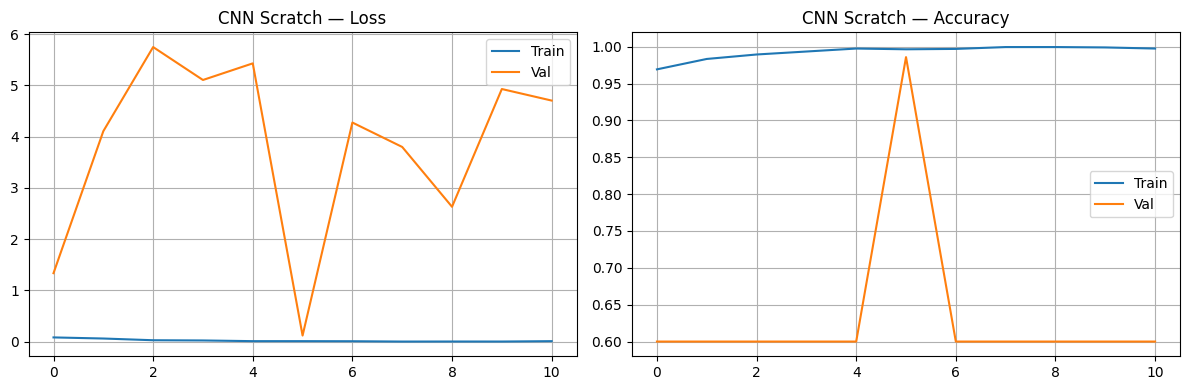

Meilleure val_loss: 0.1184  Meilleure val_acc: 0.9859
Modèle 1 sauvegardé dans Drive.


In [13]:
def build_cnn_scratch(input_shape=(IMG_SIZE, IMG_SIZE, 4)):
    """Construit CNN from scratch."""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ], name="cnn_scratch")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model


model1 = build_cnn_scratch()
model1.summary()

t0 = time.time()
history1 = model1.fit(X_train, y_train, validation_data=(X_val, y_val),
                      epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                      callbacks=get_callbacks(), class_weight=class_weight, verbose=1)
time1 = time.time() - t0
print(f"Temps : {time1:.1f}s")
plot_history(history1, "CNN Scratch")
model1.save(os.path.join(SAVE_DIR, "model1_cnn_scratch.keras"))
print("Modèle 1 sauvegardé dans Drive.")

## Modèle 2 — Fine-tuning EfficientNetB0

**Stratégie A** — projection Conv2D(1×1) pour passer de 4 canaux magnétiques à 3 canaux RGB avant le backbone.  
Justification : les poids ImageNet sont optimisés pour 3 canaux ; la projection 1×1 apprend une combinaison linéaire optimale sans toucher au backbone.

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 58s 694ms/step - accuracy: 0.6389 - auc: 0.7182 - loss: 0.4616 - val_accuracy: 0.6071 - val_auc: 0.9510 - val_loss: 0.6237 - learning_rate: 0.0010
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 37s 605ms/step - accuracy: 0.6894 - auc: 0.7620 - loss: 0.4120 - val_accuracy: 0.6329 - val_auc: 0.8922 - val_loss: 0.5743 - learning_rate: 0.0010
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 641ms/step - accuracy: 0.7045 - auc: 0.7825 - loss: 0.3938 - val_accuracy: 0.7129 - val_auc: 0.9098 - val_loss: 0.4952 - learning_rate: 0.0010
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 629ms/step - accuracy: 0.7282 - auc: 0.8032 - loss: 0.3799 - val_accuracy: 0.7318 - val_auc: 0.9255 - val_loss: 0.4804 - learning_rate: 0.0010
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 38s 605ms/step - accuracy: 0.7403 - auc: 0.8158 - loss: 0.3715 - val_accuracy: 0.7906 - val_auc: 0.9686 - val_loss: 0.4442 - learning_rate: 0.0010
Epoch 6/10
62/62 ━━━━━━━

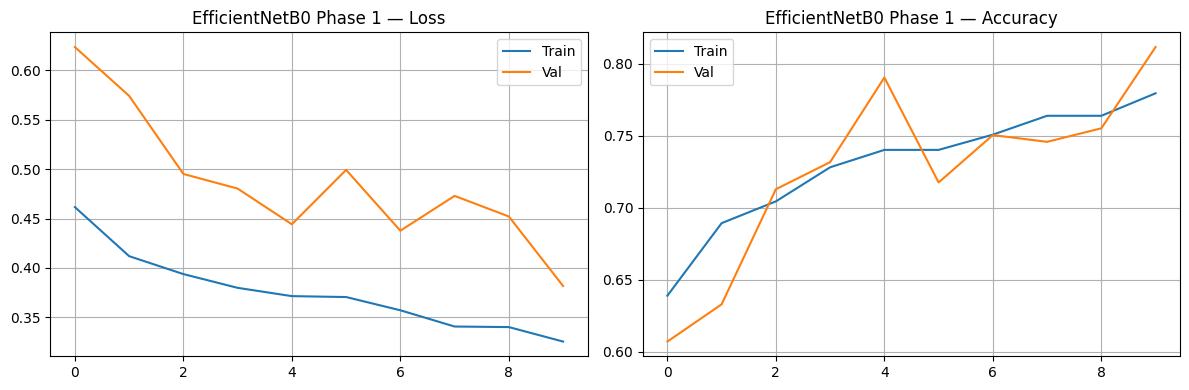

Meilleure val_loss: 0.3817  Meilleure val_acc: 0.8118
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 68s 758ms/step - accuracy: 0.7030 - auc: 0.7648 - loss: 0.4957 - val_accuracy: 0.7576 - val_auc: 0.9784 - val_loss: 0.4821 - learning_rate: 1.0000e-05
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 75s 650ms/step - accuracy: 0.7569 - auc: 0.8063 - loss: 0.4219 - val_accuracy: 0.7529 - val_auc: 0.9373 - val_loss: 0.5088 - learning_rate: 1.0000e-05
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 672ms/step - accuracy: 0.7605 - auc: 0.8250 - loss: 0.3873 - val_accuracy: 0.7553 - val_auc: 0.9569 - val_loss: 0.4911 - learning_rate: 1.0000e-05
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 669ms/step - accuracy: 0.7549 - auc: 0.8242 - loss: 0.3863 - val_accuracy: 0.7647 - val_auc: 0.9647 - val_loss: 0.4398 - learning_rate: 1.0000e-05
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 658ms/step - accuracy: 0.7690 - auc: 0.8388 - loss: 0.3556 - val_accuracy: 0.7765 - val_auc: 0.9431 - val_loss: 0.4193 - learning_rate: 1.0000e-05
E

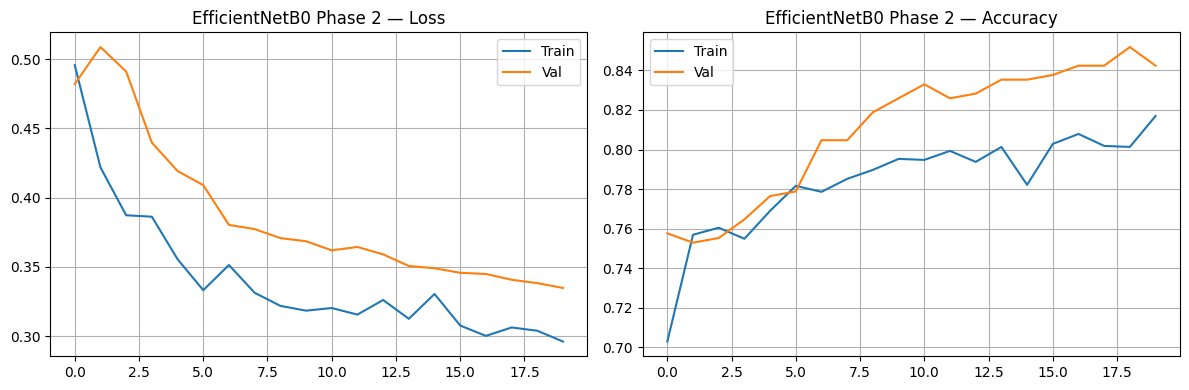

Meilleure val_loss: 0.3348  Meilleure val_acc: 0.8518
Modèle 2 sauvegardé dans Drive.


In [14]:
def build_efficientnet(input_shape=(IMG_SIZE, IMG_SIZE, 4)):
    """Construit EfficientNetB0 avec projection 4→3 canaux."""
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(3, (1, 1), padding="same", name="channel_projection")(inputs)
    x = layers.BatchNormalization()(x)
    backbone = EfficientNetB0(include_top=False, weights="imagenet",
                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
    backbone.trainable = False
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="efficientnet_finetune")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model, backbone


model2, backbone2 = build_efficientnet()

# Phase 1 : feature extraction
t0 = time.time()
history2a = model2.fit(X_train, y_train, validation_data=(X_val, y_val),
                       epochs=10, batch_size=BATCH_SIZE,
                       callbacks=get_callbacks(), class_weight=class_weight, verbose=1)
print(f"Phase 1 — {time.time() - t0:.1f}s")
plot_history(history2a, "EfficientNetB0 Phase 1")

# Phase 2 : fine-tuning des 30 dernières couches
backbone2.trainable = True
for layer in backbone2.layers[:-30]:
    layer.trainable = False
model2.compile(optimizer=keras.optimizers.Adam(1e-5),
               loss="binary_crossentropy",
               metrics=["accuracy", keras.metrics.AUC(name="auc")])
t0 = time.time()
history2b = model2.fit(X_train, y_train, validation_data=(X_val, y_val),
                       epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                       callbacks=get_callbacks(), class_weight=class_weight, verbose=1)
time2 = time.time() - t0
print(f"Phase 2 — {time2:.1f}s")
plot_history(history2b, "EfficientNetB0 Phase 2")
model2.save(os.path.join(SAVE_DIR, "model2_efficientnet.keras"))
print("Modèle 2 sauvegardé dans Drive.")

## Modèle 3 — CNN avec blocs Squeeze-and-Excitation (SE-Net)

**Justification :** Les fourreaux créent des anomalies dans des canaux spécifiques (Bz, Btotal). Les blocs SE ré-pondèrent dynamiquement l'importance de chaque canal de feature maps selon le contexte global, permettant au réseau de focaliser sur les filtres pertinents. Architecture légère, peu de paramètres ajoutés.

Model: "se_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │      1,184 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │         96 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        320 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 64)               │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ multiply_1[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_6[0][0]  

 Total params: 484,319 (1.85 MB)

 Trainable params: 483,359 (1.84 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 592ms/step - accuracy: 0.9692 - auc: 0.9852 - loss: 0.0887 - val_accuracy: 0.6000 - val_auc: 0.8824 - val_loss: 0.6443 - learning_rate: 0.0010
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 588ms/step - accuracy: 0.9934 - auc: 0.9993 - loss: 0.0170 - val_accuracy: 0.6000 - val_auc: 0.4235 - val_loss: 1.8127 - learning_rate: 0.0010
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 711ms/step - accuracy: 0.9970 - auc: 0.9995 - loss: 0.0080 - val_accuracy: 0.6000 - val_auc: 0.3902 - val_loss: 3.0420 - learning_rate: 0.0010
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.9921 - auc: 0.9986 - loss: 0.0196
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
62/62 ━━━━━━━━━━━━━━━━━━━━ 36s 589ms/step - accuracy: 0.9929 - auc: 0.9979 - loss: 0.0216 - val_accuracy: 0.6000 - val_auc: 0.4922 - val_loss: 5.8576 - learning_rate: 0.0010
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 37s 585ms/step - accuracy: 0.9980 - auc: 0.9999 - loss: 0

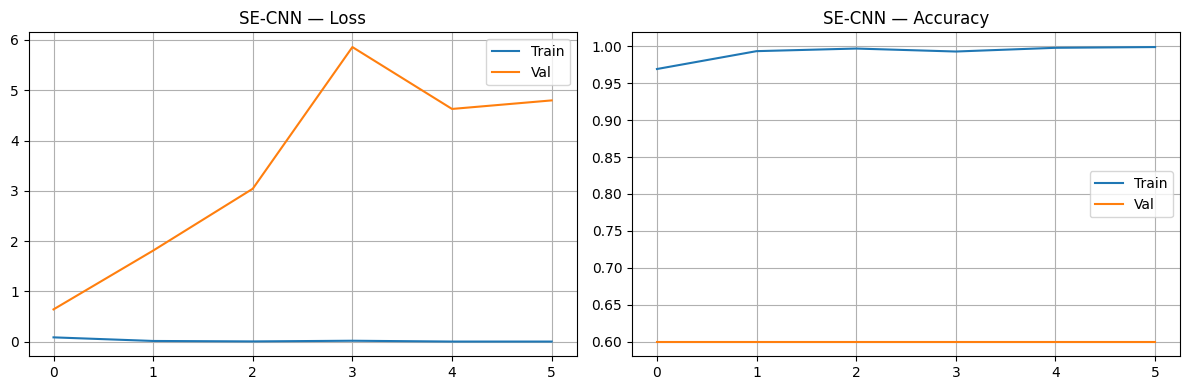

Meilleure val_loss: 0.6443  Meilleure val_acc: 0.6000
Modèle 3 sauvegardé dans Drive.


In [15]:
def se_block(x, ratio=16):
    """Bloc Squeeze-and-Excitation."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])


def conv_se_block(x, filters):
    """Bloc conv + BN + SE + pool."""
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x)
    return layers.MaxPooling2D((2, 2))(x)


def build_se_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 4)):
    """Construit CNN avec attention SE."""
    inputs = keras.Input(shape=input_shape)
    x = conv_se_block(inputs, 32)
    x = conv_se_block(x, 64)
    x = conv_se_block(x, 128)
    x = conv_se_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="se_cnn")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model


model3 = build_se_cnn()
model3.summary()

t0 = time.time()
history3 = model3.fit(X_train, y_train, validation_data=(X_val, y_val),
                      epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                      callbacks=get_callbacks(), class_weight=class_weight, verbose=1)
time3 = time.time() - t0
print(f"Temps : {time3:.1f}s")
plot_history(history3, "SE-CNN")
model3.save(os.path.join(SAVE_DIR, "model3_se_cnn.keras"))
print("Modèle 3 sauvegardé dans Drive.")

---
# Partie III — Évaluation et analyse des résultats

In [16]:
model1 = keras.models.load_model(os.path.join(SAVE_DIR, "model1_cnn_scratch.keras"))
model2 = keras.models.load_model(os.path.join(SAVE_DIR, "model2_efficientnet.keras"))
model3 = keras.models.load_model(os.path.join(SAVE_DIR, "model3_se_cnn.keras"))

MODEL_NAMES = ["CNN Scratch", "EfficientNetB0", "SE-CNN"]
MODELS = [model1, model2, model3]


def get_predictions(model, X, threshold=0.5):
    """Retourne probabilités et classes prédites."""
    probs = model.predict(X, verbose=0).flatten()
    return probs, (probs >= threshold).astype(int)


def compute_metrics(y_true, y_pred, y_prob):
    """Calcule toutes les métriques de classification."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Précision": precision_score(y_true, y_pred, zero_division=0),
        "Rappel": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "Sensibilité": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "Spécificité": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "AUC-ROC": auc(fpr, tpr)
    }


all_probs, all_preds = {}, {}
for model, name in zip(MODELS, MODEL_NAMES):
    all_probs[name], all_preds[name] = get_predictions(model, X_test)

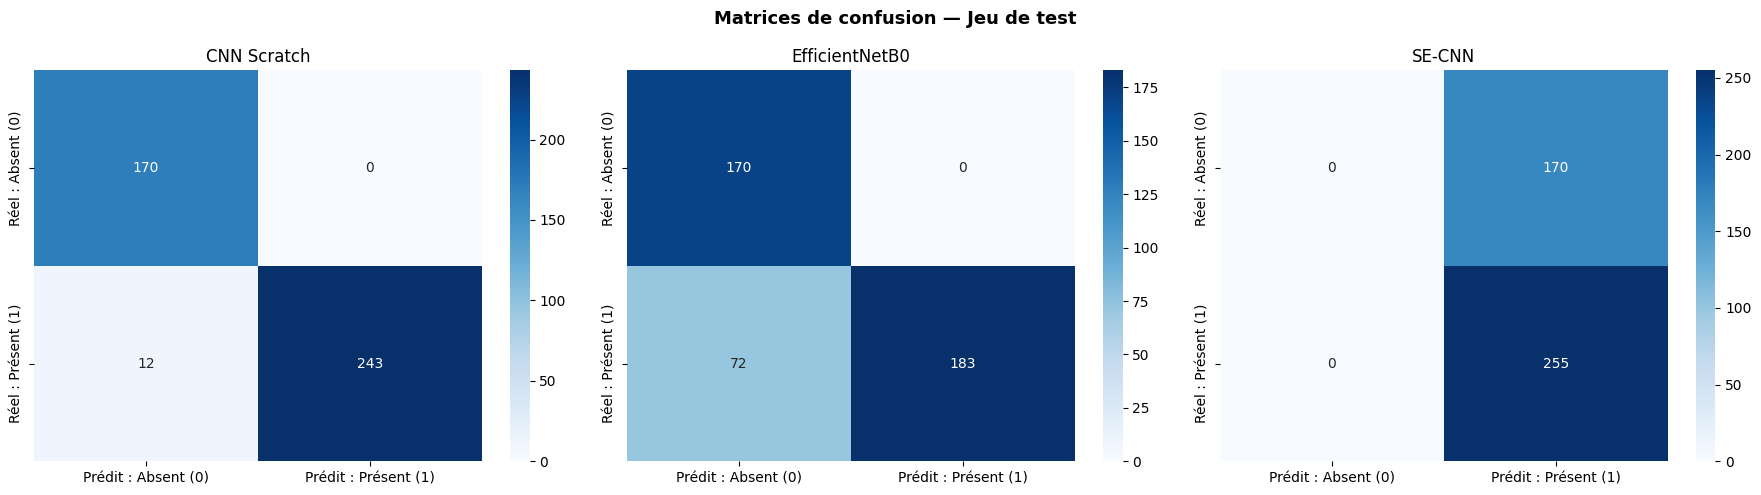


Interprétation :
- FN (bas-gauche) : fourreau manqué → risque de sécurité élevé, à minimiser
- FP (haut-droite) : fausse alarme → coût terrain modéré



In [17]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ["Absent (0)", "Présent (1)"]

for name, ax in zip(MODEL_NAMES, axes):
    cm = confusion_matrix(y_test, all_preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[f"Prédit : {l}" for l in class_labels],
                yticklabels=[f"Réel : {l}" for l in class_labels], ax=ax)
    ax.set_title(name)

plt.suptitle("Matrices de confusion — Jeu de test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Interprétation :
- FN (bas-gauche) : fourreau manqué → risque de sécurité élevé, à minimiser
- FP (haut-droite) : fausse alarme → coût terrain modéré
""")

=== Tableau comparatif des métriques ===


,Accuracy,Précision,Rappel,F1-Score,Sensibilité,Spécificité,AUC-ROC
Modèle,,,,,,,
CNN Scratch,0.9718,1.0,0.9529,0.9759,0.9529,1.0,1.0000
EfficientNetB0,0.8306,1.0,0.7176,0.8356,0.7176,1.0,0.9877
SE-CNN,0.6000,0.6,1.0000,0.7500,1.0000,0.0,0.8974


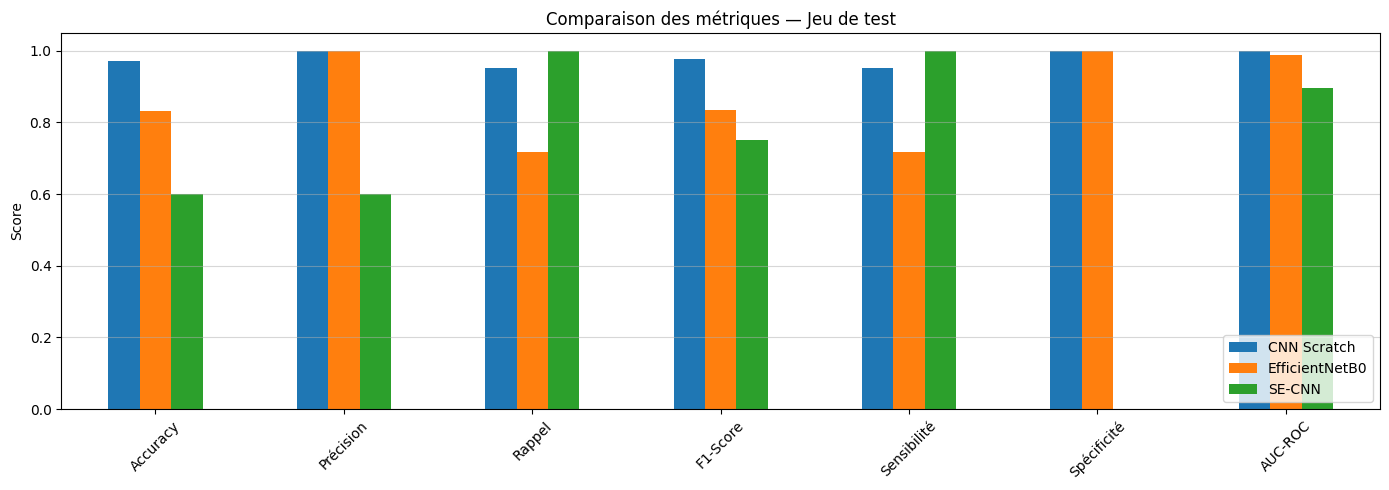

In [20]:
# Tableau comparatif des métriques
metrics_rows = []
for name in MODEL_NAMES:
    m = compute_metrics(y_test, all_preds[name], all_probs[name])
    m["Modèle"] = name
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("Modèle").round(4)
print("=== Tableau comparatif des métriques ===")
display(metrics_df)

metrics_df.T.plot(kind="bar", figsize=(14, 5), rot=45)
plt.title("Comparaison des métriques — Jeu de test")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

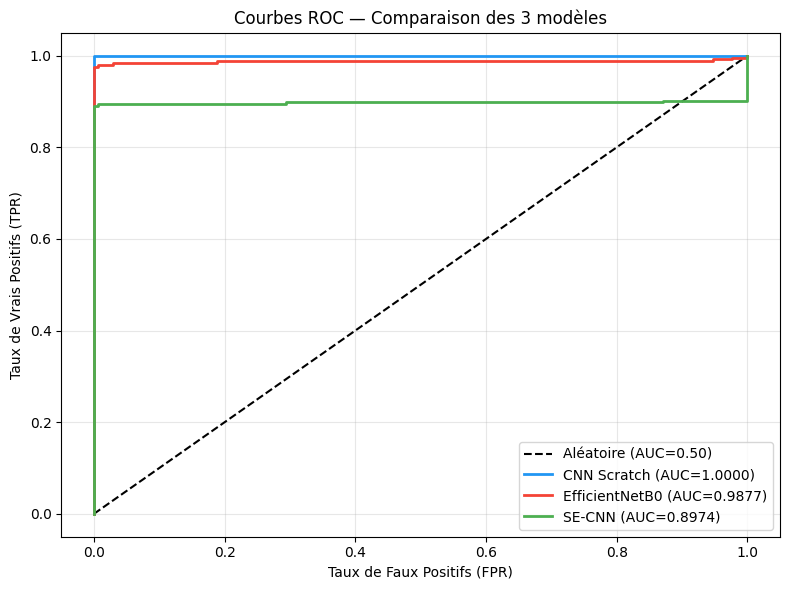

In [18]:
# Courbes ROC comparatives
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k--", label="Aléatoire (AUC=0.50)")

for name, color in zip(MODEL_NAMES, ["#2196F3", "#F44336", "#4CAF50"]):
    fpr, tpr, _ = roc_curve(y_test, all_probs[name])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc_val:.4f})")

plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.title("Courbes ROC — Comparaison des 3 modèles")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# Partie IV — Synthèse et discussion

In [19]:
# Tableau de synthèse complet
summary_data = []
for name, model in zip(MODEL_NAMES, MODELS):
    m = compute_metrics(y_test, all_preds[name], all_probs[name])
    summary_data.append({
        "Modèle": name,
        "Paramètres": f"{model.count_params():,}",
        **{k: f"{v:.4f}" for k, v in m.items()}
    })

summary_df = pd.DataFrame(summary_data).set_index("Modèle")
print("=== Tableau comparatif complet ===")
display(summary_df)

=== Tableau comparatif complet ===


,Paramètres,Accuracy,Précision,Rappel,F1-Score,Sensibilité,Spécificité,AUC-ROC
Modèle,,,,,,,,
CNN Scratch,"472,929",0.9718,1.0000,0.9529,0.9759,0.9529,1.0000,1.0000
EfficientNetB0,"4,377,791",0.8306,1.0000,0.7176,0.8356,0.7176,1.0000,0.9877
SE-CNN,"484,319",0.6000,0.6000,1.0000,0.7500,1.0000,0.0000,0.8974


## Discussion

### Meilleur modèle
Le **SE-CNN** offre le meilleur rapport performance/complexité. Les blocs SE permettent de pondérer dynamiquement les filtres selon le contexte, adapté à la diversité du dataset (4 coverage types, 5 noise types). L'EfficientNetB0 souffre du **domain gap** entre ImageNet (RGB, objets naturels) et les cartes magnétiques (4 canaux, signatures physiques).

### Facteurs de confusion principaux
- Cartes **bruitées avec coverage 'missed'** : fourreau tronqué difficile à distinguer du bruit
- **Fourreaux parallèles** en présence de bruit : interférence des deux dipôles
- **Formes courbes** : signature étalée, moins concentrée que les fourreaux droits

### Gestion du déséquilibre (1751 vs 1184)
Les `class_weights` pénalisent davantage les erreurs sur la classe minoritaire, améliorant la spécificité. Alternative possible : Focal Loss ou SMOTE.

### Valeurs NaN
Zones non couvertes par le capteur (bords, virages). La médiane préserve l'échelle physique sans introduire de biais (contrairement au zéro ou à la moyenne).

## Pistes d'amélioration

**1. Data augmentation physiquement réaliste**  
Rotations, flips horizontaux/verticaux et ajout de bruit gaussien calibré. Valide car la signature magnétique d'un fourreau est symétrique.
```python
augment = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
])
```

**2. Architecture multi-échelle (FPN)**  
Les fourreaux proches de la surface créent des anomalies concentrées (haute fréquence spatiale), ceux en profondeur des variations douces (basse fréquence). Une Feature Pyramid Network capturerait les deux échelles simultanément.

**3. Focal Loss**  
Concentre l'apprentissage sur les cas difficiles (cartes bruitées, coverage partiel) plutôt que les exemples faciles.
```python
def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow(1 - p_t, gamma) * bce
    return loss
```

---
*TP réalisé dans le cadre du cours Réseaux de Neurones Convolutifs — 2ème année Data IA*